In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/allsides_balanced_news_headlines-texts.csv', index_col=0)
print(df.head())
print(df.columns)


                                               title  \
0           Gun Violence Over Fourth of July Weekend   
1           Gun Violence Over Fourth of July Weekend   
2           Gun Violence Over Fourth of July Weekend   
3  Yellen Warns Congress of 'Economic Recession' ...   
4  Yellen Warns Congress of 'Economic Recession' ...   

                                                tags  \
0  ['Protests', 'Fourth Of July', 'Gun Control An...   
1  ['Protests', 'Fourth Of July', 'Gun Control An...   
2  ['Protests', 'Fourth Of July', 'Gun Control An...   
3  ['Janet Yellen', 'Debt Ceiling', 'Economic Pol...   
4  ['Janet Yellen', 'Debt Ceiling', 'Economic Pol...   

                                             heading                 source  \
0  Chicago Gun Violence Spikes and Increasingly F...  New York Times (News)   
1  ‘Bullets just came from nowhere’: Fourth of Ju...        Chicago Tribune   
2  Dozens of shootings across US mark bloody July...   New York Post (News)   
3  Federal

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import classification_report
from sklearn.utils import resample
df['full_text'] = df['heading'].fillna('') + " " + df['text'].fillna('')

title_bias_counts = df.groupby('title')['bias_rating'].nunique()
grouped = df.groupby('title')
valid_titles = grouped.filter(lambda x: len(x) == 3 and x['bias_rating'].nunique() == 3)['title'].unique()

df_shared = df[df['title'].isin(valid_titles)].copy()
df_remaining = df[~df.index.isin(df_shared.index)]

min_class_size = df_remaining['bias_rating'].value_counts().min()  

balanced_remaining = pd.concat([
    resample(g, replace=False, n_samples=min_class_size, random_state=42)
    for _, g in df_remaining.groupby('bias_rating')
])

balanced_df = pd.concat([df_shared, balanced_remaining]).sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
from collections import defaultdict

label_to_texts = defaultdict(list)

for _, row in balanced_df.iterrows():
    label = row['bias_rating']
    text = row['full_text']
    if pd.notna(text) and isinstance(text, str):
        label_to_texts[label].append(text)

for label in label_to_texts:
    print(f"{label}: {len(label_to_texts[label])} samples")


center: 4253 samples
right: 4253 samples
left: 4253 samples


In [ ]:
import random

def generate_contrastive_pairs(label_to_texts, num_pairs=10000):
    pairs = []
    labels = list(label_to_texts.keys())

    for _ in range(num_pairs):
        anchor_label = random.choice(labels)
        anchor_text = random.choice(label_to_texts[anchor_label])

        positive_text = random.choice([
            t for t in label_to_texts[anchor_label] if t != anchor_text
        ])
        pairs.append((anchor_text, positive_text, 1)) 

        negative_label = random.choice([l for l in labels if l != anchor_label])
        negative_text = random.choice(label_to_texts[negative_label])
        pairs.append((anchor_text, negative_text, 0)) 

    return pairs


In [ ]:
pairs = generate_contrastive_pairs(label_to_texts)
print(f"Generated {len(pairs)} total pairs (positive + negative)")


Generated 20000 total pairs (positive + negative)


In [ ]:
pip install -U sentence-transformers


In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses, models
from torch.utils.data import DataLoader
import torch


In [ ]:
from sentence_transformers import InputExample

train_examples = [
    InputExample(texts=[text1, text2], label=float(label))
    for text1, text2, label in pairs
]


In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses, models

model_name = 'bucketresearch/politicalBiasBERT'

word_embedding_model = models.Transformer(model_name)
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)

model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
model = model.to('cuda')


In [ ]:
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)
train_loss = losses.ContrastiveLoss(model=model)


In [ ]:
!pip install datasets


In [ ]:
from datasets import Dataset
num_epochs = 5  

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=num_epochs,
    warmup_steps=100,
    show_progress_bar=True,
    use_amp=True  
)


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: gulligulli22 (gulligulli22-university-of-missouri-system) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,0.033000
1000,0.030700
1500,0.028600
2000,0.026600
2500,0.024100
3000,0.021200


In [ ]:
model.save('/content/drive/My Drive/bias_simcse_model_1epoch')


In [ ]:
emb = model.encode("Tax cuts benefit the economy", convert_to_tensor=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

texts = balanced_df['full_text'].tolist()
labels = balanced_df['bias_rating'].tolist()

le = LabelEncoder()
y = le.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
# model = SentenceTransformer('/content/bias_simcse_model')

X_train_emb = model.encode(X_train, convert_to_tensor=True, device='cuda')
X_test_emb = model.encode(X_test, convert_to_tensor=True, device='cuda')


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train_np = X_train_emb.cpu().numpy()
X_test_np = X_test_emb.cpu().numpy()

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_np, y_train)

y_pred = clf.predict(X_test_np)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

      center       0.55      0.57      0.56       850
        left       0.51      0.48      0.49       851
       right       0.47      0.48      0.48       851

    accuracy                           0.51      2552
   macro avg       0.51      0.51      0.51      2552
weighted avg       0.51      0.51      0.51      2552



In [ ]:
############################

In [ ]:
missouri_topic_0 = pd.read_csv('/content/drive/My Drive/missouri_topic_0.csv')

In [ ]:
missouri_topic_0['full_text'] = missouri_topic_0['title'].fillna('') + " " + missouri_topic_0['news'].fillna('')

In [ ]:
model = SentenceTransformer('/content/drive/My Drive/bias_simcse_model_1epoch')
emb = model.encode(missouri_topic_0['full_text'], convert_to_tensor=True, device='cuda')
emb_np = emb.cpu().numpy()
missouri_topic_0['pred']=clf.predict(emb_np)

NameError: name 'clf' is not defined

In [ ]:
missouri_topic_0.to_csv('/content/drive/My Drive/missouri_labeled.csv', index=False)


In [ ]:
############################

In [ ]:
import pandas as pd
missouri_labeled = pd.read_csv('/content/drive/My Drive/missouri_labeled.csv')

In [ ]:
import numpy as np
unique, counts = np.unique(missouri_labeled['pred'], return_counts=True)
dict(zip(unique, counts))

{np.int64(0): np.int64(6125),
 np.int64(1): np.int64(4977),
 np.int64(2): np.int64(31309)}

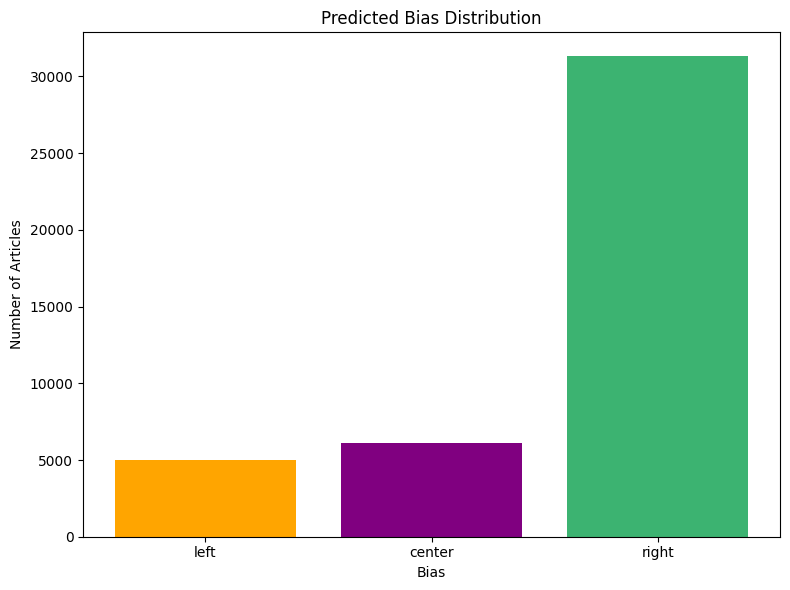

In [ ]:
import matplotlib.pyplot as plt

label_order = ['left', 'center', 'right']
color_map = {
    'left': 'orange',
    'center': 'purple',
    'right': 'mediumseagreen'
}

bias_counts = missouri_labeled['pred_label'].value_counts().reindex(label_order)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(bias_counts.index, bias_counts.values, color=[color_map[label] for label in label_order])

# for bar in bars:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2, height + 500, f'{int(height):,}', ha='center', va='bottom')

ax.set_title("Predicted Bias Distribution")
ax.set_xlabel("Bias")
ax.set_ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from urllib.parse import urlparse

missouri_labeled['domain'] = missouri_labeled['url_news'].apply(lambda x: urlparse(str(x)).netloc if pd.notnull(x) else None)

print("Unique news outlets:", missouri_labeled['domain'].nunique())

Unique news outlets: 157


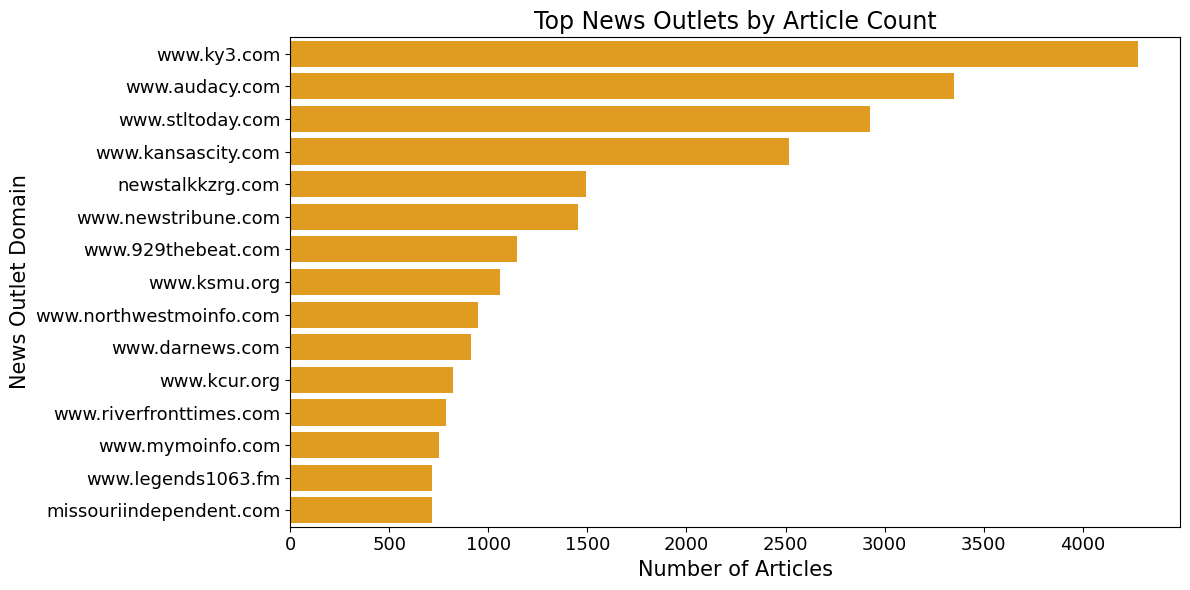

In [ ]:
import seaborn as sns

top_domains = missouri_labeled['domain'].value_counts().head(15)

plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 13

plt.figure(figsize=(12, 6))
sns.barplot(x=top_domains.values, y=top_domains.index, color='orange')
plt.title('Top News Outlets by Article Count', size=17)
plt.xlabel('Number of Articles', size=15)
plt.ylabel('News Outlet Domain', size=15)
plt.tight_layout()
plt.show()

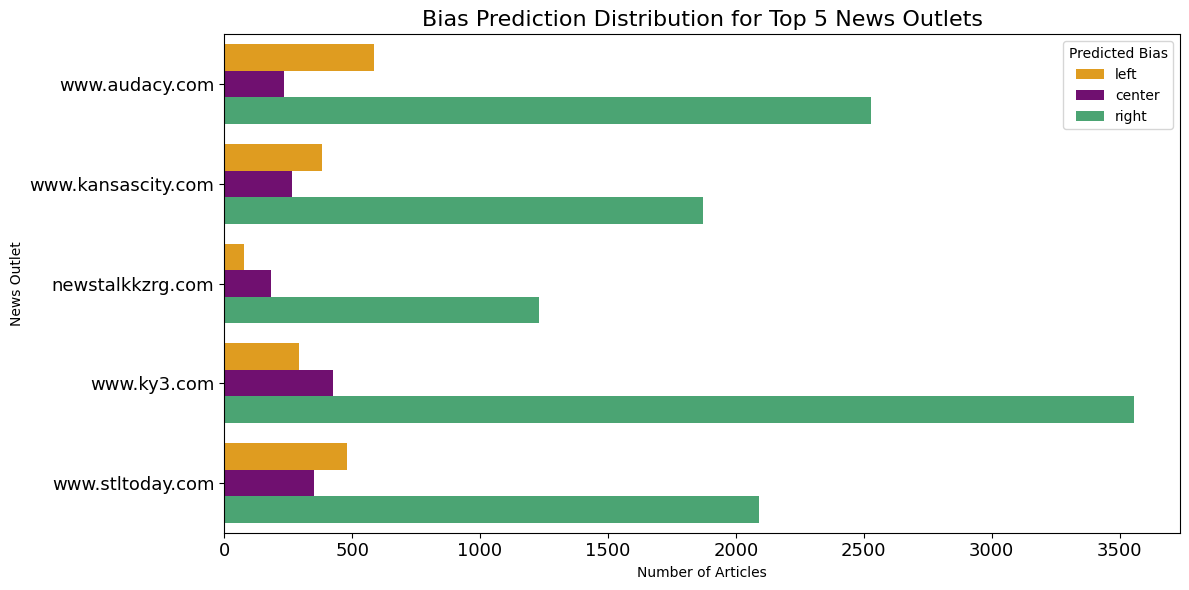

In [ ]:
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

missouri_labeled['domain'] = missouri_labeled['url_news'].apply(
    lambda x: urlparse(str(x)).netloc if pd.notnull(x) else None
)

top5_domains = missouri_labeled['domain'].value_counts().head(5).index.tolist()
filtered_df = missouri_labeled[missouri_labeled['domain'].isin(top5_domains)]

label_order = ['left', 'center', 'right']
color_map = {
    'left': 'orange',
    'center': 'purple',
    'right': 'mediumseagreen'  
}

plt.figure(figsize=(12, 6))
sns.countplot(
    data=filtered_df,
    y='domain',
    hue='pred_label',
    hue_order=label_order,
    palette=color_map
)
plt.title('Bias Prediction Distribution for Top 5 News Outlets', fontsize=16)
plt.xlabel('Number of Articles')
plt.ylabel('News Outlet')
plt.legend(title='Predicted Bias')
plt.tight_layout()
plt.show()


In [ ]:
#################################

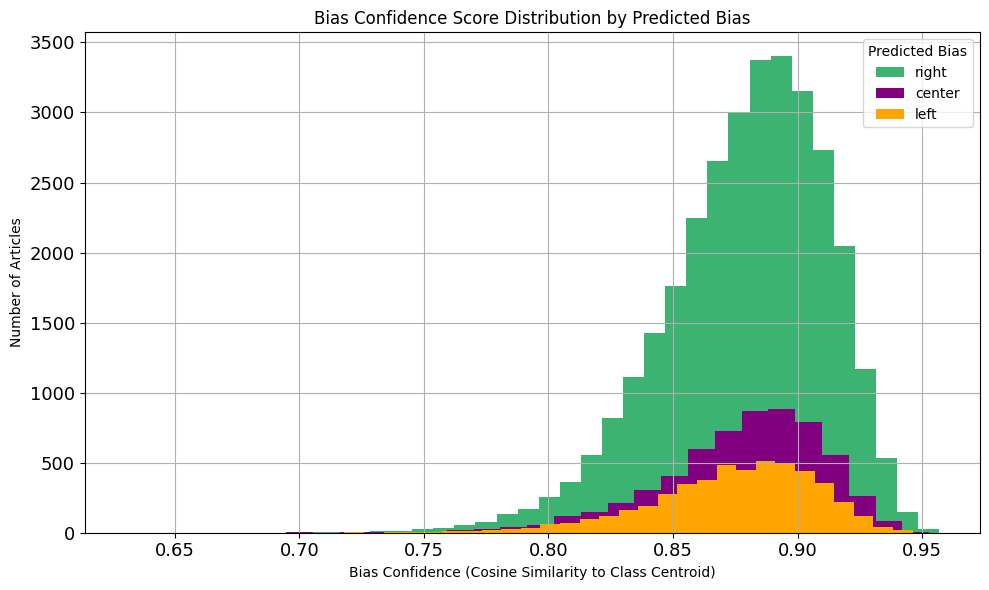

In [ ]:

from sklearn.metrics.pairwise import cosine_similarity


missouri_labeled['embedding'] = [emb.cpu().numpy() for emb in emb]

centroids = {
    label: np.mean(np.stack(missouri_labeled[missouri_labeled['pred_label'] == label]['embedding'].tolist()), axis=0)
    for label in label_order
}

missouri_labeled['bias_confidence'] = missouri_labeled.apply(
    lambda row: cosine_similarity([row['embedding']], [centroids[row['pred_label']]])[0][0], axis=1
)

class_counts = missouri_labeled['pred_label'].value_counts()

sorted_labels = class_counts.sort_values(ascending=False).index.tolist()

color_map = {
    'left': 'orange',
    'center': 'purple',
    'right': 'mediumseagreen'
}

plt.figure(figsize=(10, 6))
for label in sorted_labels:
    subset = missouri_labeled[missouri_labeled['pred_label'] == label]
    plt.hist(subset['bias_confidence'], bins=30, label=label, color=color_map[label])

plt.title("Bias Confidence Score Distribution by Predicted Bias")
plt.xlabel("Bias Confidence (Cosine Similarity to Class Centroid)")
plt.ylabel("Number of Articles")
plt.legend(title="Predicted Bias")
plt.grid(True)
plt.tight_layout()
plt.show()



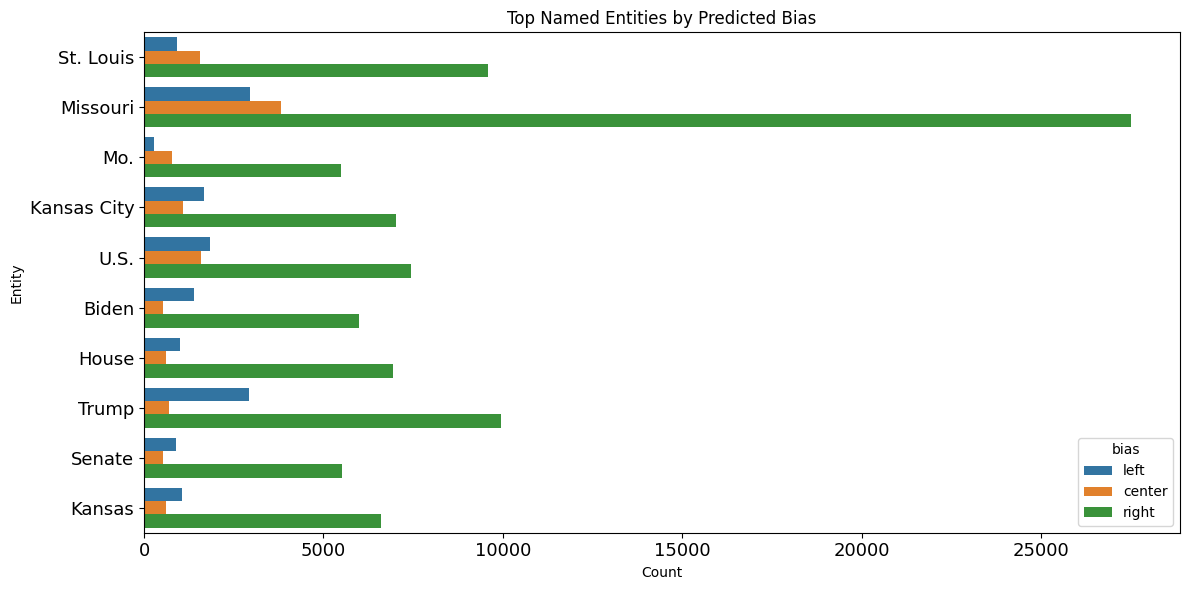

In [ ]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

entity_biases = []
for _, row in missouri_topic_0.iterrows():
    doc = nlp(row['full_text'])
    entities = [ent.text for ent in doc.ents if ent.label_ in ['PERSON', 'ORG', 'GPE']]
    entity_biases.extend([(ent, row['pred_label']) for ent in entities])

entity_df = pd.DataFrame(entity_biases, columns=['entity', 'bias'])
top_entities = entity_df['entity'].value_counts().head(10).index
filtered = entity_df[entity_df['entity'].isin(top_entities)]

plt.figure(figsize=(12, 6))
sns.countplot(data=filtered, y='entity', hue='bias', hue_order=['left', 'center', 'right'])
plt.title("Top Named Entities by Predicted Bias")
plt.xlabel("Count")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()


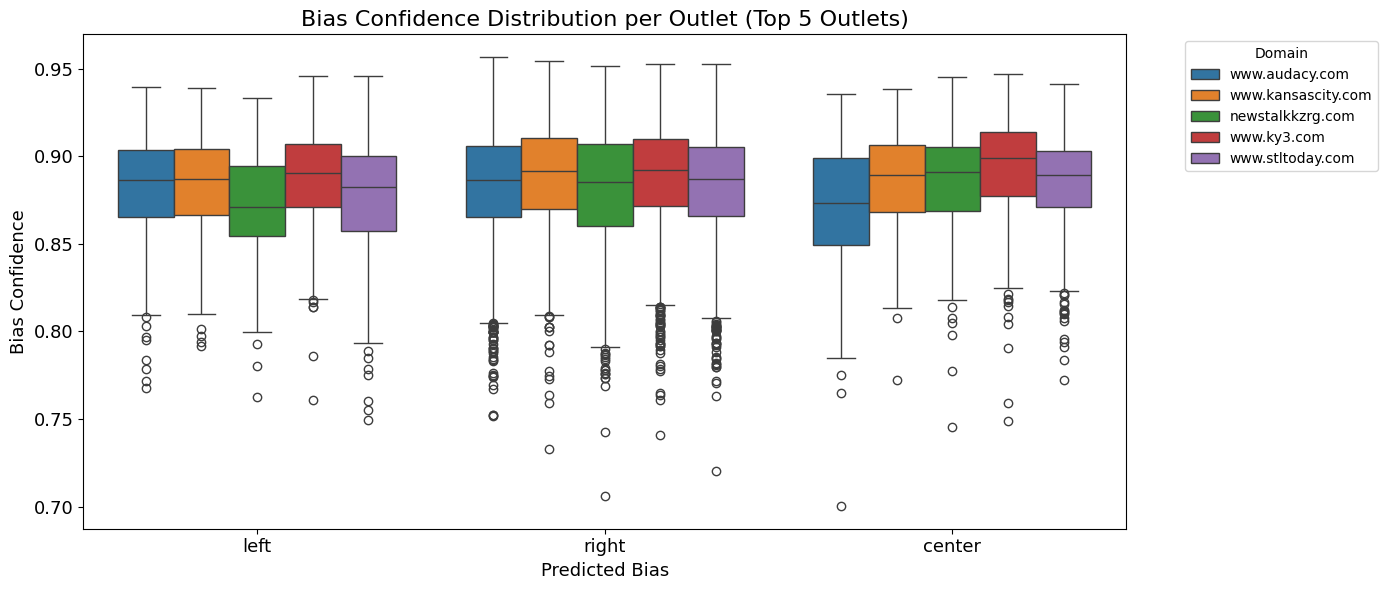

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



top5_domains = missouri_labeled['domain'].value_counts().head(5).index.tolist()

filtered_df = missouri_labeled[missouri_labeled['domain'].isin(top5_domains)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=filtered_df,
    x='pred_label',
    y='bias_confidence',
    hue='domain'
)

plt.title('Bias Confidence Distribution per Outlet (Top 5 Outlets)', fontsize=16)
plt.xlabel('Predicted Bias', fontsize=13)
plt.ylabel('Bias Confidence', fontsize=13)
plt.legend(title='Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


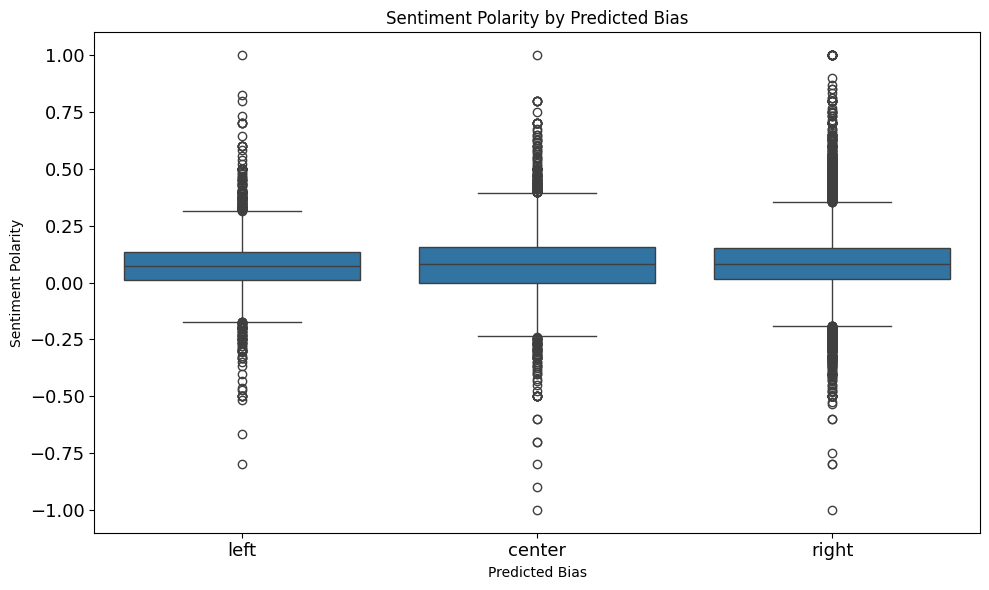

In [ ]:
from textblob import TextBlob

missouri_topic_0['sentiment'] = missouri_topic_0['full_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(10, 6))
sns.boxplot(data=missouri_topic_0, x='pred_label', y='sentiment', order=['left', 'center', 'right'])
plt.title("Sentiment Polarity by Predicted Bias")
plt.xlabel("Predicted Bias")
plt.ylabel("Sentiment Polarity")
plt.tight_layout()
plt.show()


In [ ]:
import shap
import torch
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer

model_path = '/content/drive/My Drive/bias_simcse_model_1epoch'
model = SentenceTransformer(model_path).to('cuda')
tokenizer = AutoTokenizer.from_pretrained("bucketresearch/politicalBiasBERT")

samples = {}
for label in ['left', 'center', 'right']:
    samples[label] = missouri_labeled[missouri_labeled['pred_label'] == label].sample(1, random_state=42)['full_text'].values[0]

def predict_fn(texts):
    return model.encode(texts, convert_to_tensor=True).cpu().numpy()

explainer = shap.Explainer(predict_fn, tokenizer)

shap_values = explainer(list(samples.values()))

for i, (label, text) in enumerate(samples.items()):
    print(f"\n SHAP Explanation for {label.upper()}-biased article:")
    shap.plots.text(shap_values[i])

config.json:   0%|          | 0.00/909 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  67%|██████▋   | 2/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:27, 13.93s/it]



 SHAP Explanation for LEFT-biased article:
Buffered data was truncated after reaching the output size limit.

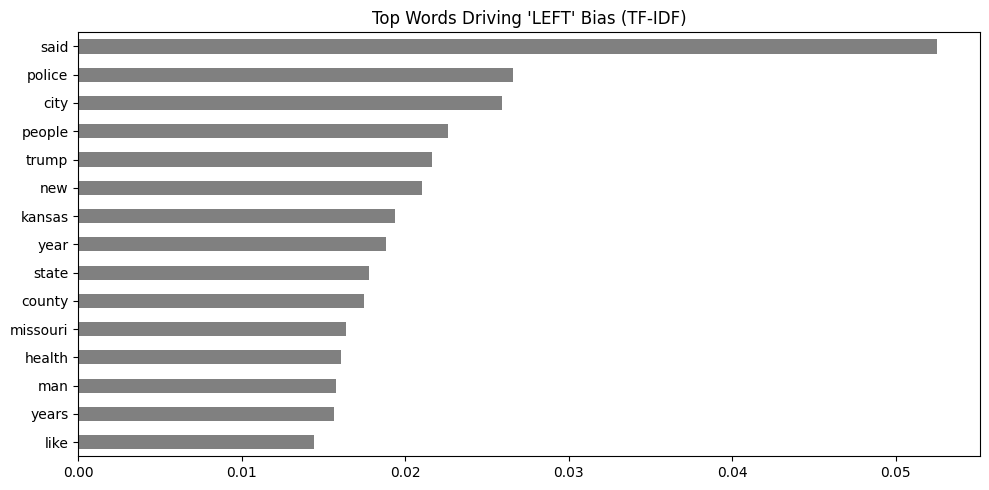

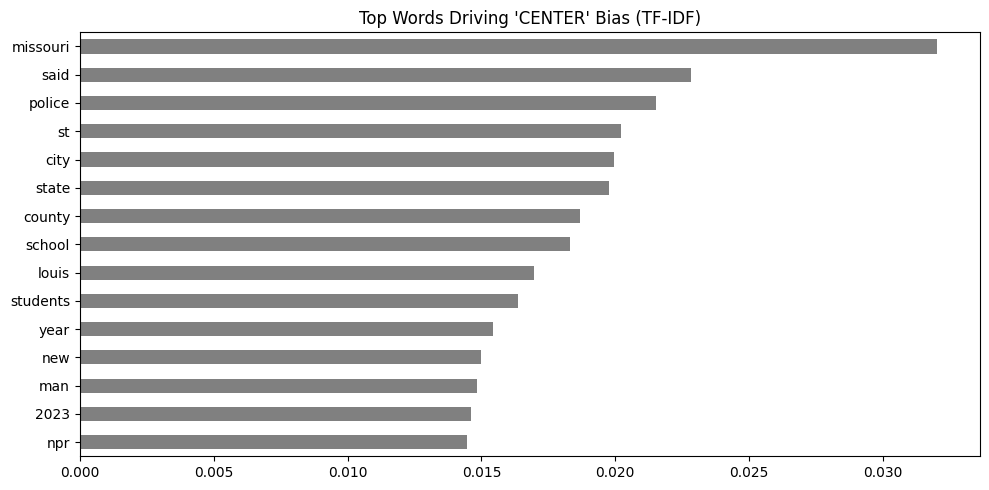

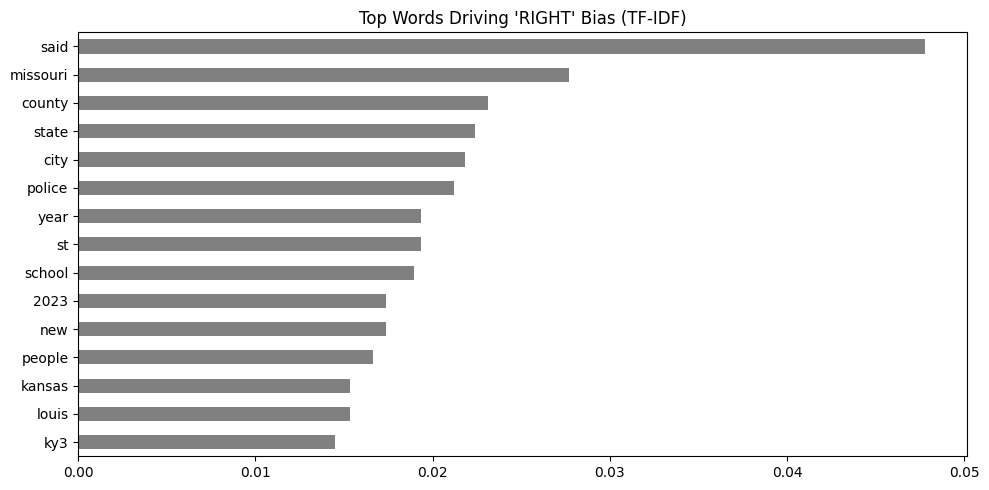

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(missouri_labeled['full_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df['label'] = missouri_labeled['pred_label'].values

top_words = {}
for label in ['left', 'center', 'right']:
    label_df = tfidf_df[tfidf_df['label'] == label].drop('label', axis=1)
    top_words[label] = label_df.mean().sort_values(ascending=False).head(15)

for label in top_words:
    plt.figure(figsize=(10, 5))
    top_words[label].plot(kind='barh', title=f"Top Words Driving '{label.upper()}' Bias (TF-IDF)", color='gray')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
